# **Solving Functional Equations**

**Example:** Solving the functional equation  $f(x+y) = f(x)  f(y)$, with  $x$ and $y$ real numbers. Its solution is an exponential function, $f(x) = a^x$, with a real nonzero constant. In the next code we consider the initial condition $f(1)=2$, so the solution will be $f(x) = 2^x$.

I0000 00:00:1783203957.444088   18128 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783203959.770418   18128 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783203968.687341   18128 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/efra/anaconda3/envs/dl4physics/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1783203972.772187   18128 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA er

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.6413
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1445
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0360
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0132
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0108
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0096
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0083
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0076
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0065
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0056
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0057
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0049
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0043
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0042
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0031
Epoc

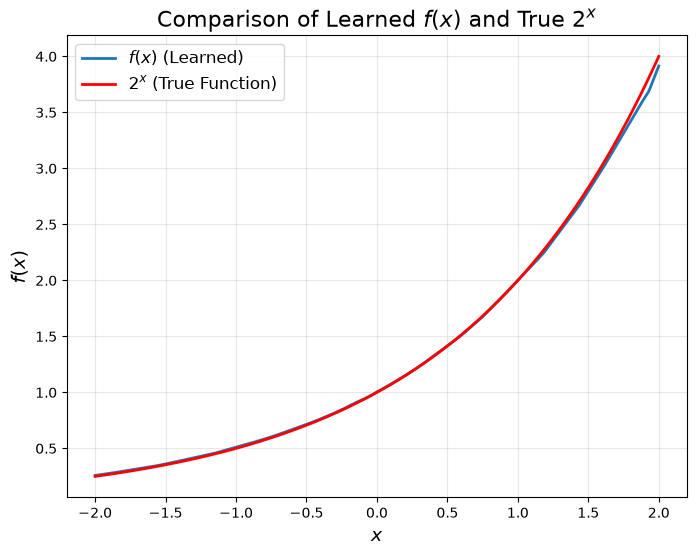

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Generate random samples for x_i and y_i
x_samples = np.random.uniform(-2, 2, 1000).reshape(-1, 1)
y_samples = np.random.uniform(-2, 2, 1000).reshape(-1, 1)

# Compute x + y for functional equation training
xy_samples = x_samples + y_samples

# Build the neural network
model = Sequential([
    Dense(100, activation='relu', input_dim=1),
    # First hidden layer with 100 neurons
    Dense(50, activation='relu'),
    # Second hidden layer
    Dense(1)  # Output layer
])

# Define the custom loss function
def custom_loss(y_true, y_pred):
    # Functional equation loss: f(x+y) ≈ f(x)f(y)
    x_input = tf.constant(x_samples, dtype=tf.float32)
    y_input = tf.constant(y_samples, dtype=tf.float32)
    xy_input = tf.constant(xy_samples, dtype=tf.float32)

    f_x = model(x_input)  # f(x)
    f_y = model(y_input)  # f(y)
    f_xy = model(xy_input)  # f(x+y)

    functional_loss = tf.reduce_mean(tf.square(f_xy - f_x * f_y))


    # Boundary condition loss: f(1) ≈ 2
    f_1 = model(tf.constant([[1.0]], dtype=tf.float32))  # f(1)
    boundary_loss = tf.square(f_1 - 2.0)


    # Total loss: L = L_fct + L_bd
    return functional_loss + boundary_loss

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss=custom_loss)

# Dummy training data for Keras
dummy_input = np.zeros_like(x_samples)
dummy_target = np.zeros_like(x_samples)

# Train the model
model.fit(dummy_input, dummy_target, epochs=50, batch_size=32, verbose=1)

# Predict and plot the function f(x)
x_plot = np.linspace(-2, 2, 1000).reshape(-1, 1)
f_x_plot = model.predict(x_plot)

# Compute the true function y = 2^x for comparison
true_f_x = 2**x_plot

# Plot the learned function f(x) and the true function y = 2^x
plt.figure(figsize=(8, 6))
plt.plot(x_plot, f_x_plot, label="$f(x)$ (Learned)", linewidth=2)
plt.plot(x_plot, true_f_x, label="$2^x$ (True Function)", linewidth=2, color='red')
plt.title("Comparison of Learned $f(x)$ and True $2^x$", fontsize=16)
plt.xlabel("$x$", fontsize=14)
plt.ylabel("$f(x)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()


**Example:** Solving the functional equation  $f(x+y) = f(x)+f(y)$, $x$ and $y$ real numbers.Its solution is a linear function, $f(x) = cx$, with $c$ real constant. In the next code we consider the initial condition $f(1)=3$, so the solution will be $f(x) = 3x$.

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.7369
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3676
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6488
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5600
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5192
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4715
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4092
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3251
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1688
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0472
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0103
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.5905e-04
Epoch 14/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.6014e-05
Epoch 15/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.5180e-05
Ep

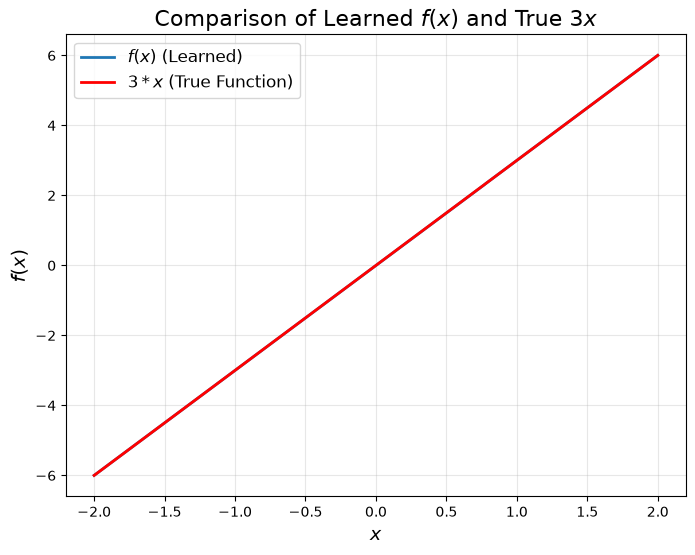

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Generate random samples for x_i and y_i
x_samples = np.random.uniform(-2, 2, 1000).reshape(-1, 1)
y_samples = np.random.uniform(-2, 2, 1000).reshape(-1, 1)

# Compute x + y for functional equation training
xy_samples = x_samples + y_samples

# Build the neural network
model = Sequential([
    Dense(10, activation='relu', input_dim=1),  # First hidden layer with 10 neurons
    #Dense(50, activation='relu'),  # Second hidden layer
    Dense(1)  # Output layer
])

# Define the custom loss function
def custom_loss(y_true, y_pred):
    # Functional equation loss: f(x+y) ≈ f(x)+f(y)
    x_input = tf.constant(x_samples, dtype=tf.float32)
    y_input = tf.constant(y_samples, dtype=tf.float32)
    xy_input = tf.constant(xy_samples, dtype=tf.float32)

    f_x = model(x_input)  # f(x)
    f_y = model(y_input)  # f(y)
    f_xy = model(xy_input)  # f(x+y)

    functional_loss = tf.reduce_mean(tf.square(f_xy - f_x - f_y))


    # Boundary condition loss: f(1) ≈ 3
    f_1 = model(tf.constant([[1.0]], dtype=tf.float32))  # f(1)
    boundary_loss = tf.square(f_1 - 3.0)


    # Total loss: L = L_fct + L_bd
    return functional_loss + boundary_loss

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss=custom_loss)

# Dummy training data for Keras
dummy_input = np.zeros_like(x_samples)
dummy_target = np.zeros_like(x_samples)

# Train the model
model.fit(dummy_input, dummy_target, epochs=30, batch_size=32, verbose=1)

# Predict and plot the function f(x)
x_plot = np.linspace(-2, 2, 1000).reshape(-1, 1)
f_x_plot = model.predict(x_plot)

# Compute the true function y = 3x for comparison
true_f_x = 3*x_plot

# Plot the learned function f(x) and the true function y = 3x
plt.figure(figsize=(8, 6))
plt.plot(x_plot, f_x_plot, label="$f(x)$ (Learned)", linewidth=2)
plt.plot(x_plot, true_f_x, label="$3*x$ (True Function)", linewidth=2, color='red')
plt.title("Comparison of Learned $f(x)$ and True $3x$", fontsize=16)
plt.xlabel("$x$", fontsize=14)
plt.ylabel("$f(x)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()